# Inroduction
The contents of this notebook seeks to explore what is possible with Feature Extractors. These feature extractors are eventually intended to obtain geometrical features from depth maps for the purpose of solving a Next Best View Problem.

Features that will be looked into in this notebook are, edges and blobs.

In [2]:
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Show the current coordinate over which the cursor is on on a figure
def on_hover(event):
    if event.inaxes:
        x, y = event.xdata, event.ydata
        print(f"Hovering over point ({x:.2f}, {y:.2f})")

def load_image_np(img_name, img_dir="testImages/"):
    return np.asarray(Image.open(img_dir+img_name).convert("RGB") )

def load_image(img_name, img_dir="testImages/"):
    return Image.open(img_dir+img_name).convert("RGB")  # load the image

def compute_depth(image):    
    depth_numpy = zoe.infer_pil(image)  # as numpy
    return depth_numpy

def compare_against_orig(image, _map, label=""):
    colored_depth = colorize(depth_map)
    fig, axs = plt.subplots(1, 2, layout="constrained")
    
    for ax, im, title in zip(axs, [image, _map], ['Base Image', label]):
      ax.imshow(im)
      ax.axis("off")
      ax.set_title(title)
    
    # Connect the 'motion_notify_event' to the custom function on_hover
    fig.canvas.mpl_connect('motion_notify_event', on_hover)
    
    plt.show()

def show_image(image, label, colorbar=True):
    _, ax = plt.subplots(layout="constrained")
    imgPlot = ax.imshow(image)
    ax.set_title(label)
    if colorbar: plt.colorbar( imgPlot, ax=ax )

from rembg import remove, new_session
def create_mask(image):
    '''
        Create a Mask out of an image
    '''
    model_name = "sam" # sam, u2net
    session = new_session(model_name)
    mask = remove(image, only_mask=True, post_process_mask=False)
    return mask
    
def mask_out(mask, _img):
    '''
        Masks out part of the image
    '''
    to_mask= np.copy(_img) # create a copy of the depth map
    to_mask[mask == 0] = 0
    return to_mask


In [3]:
# Load the ZoeD_N pretrained Model
conf = get_config("zoedepth", "infer")
model_zoe_n = build_model(conf)

##### sample prediction
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
zoe = model_zoe_n.to(DEVICE)

img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master
/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully


## Canny Edge Detector

<IPython.core.display.Javascript object>


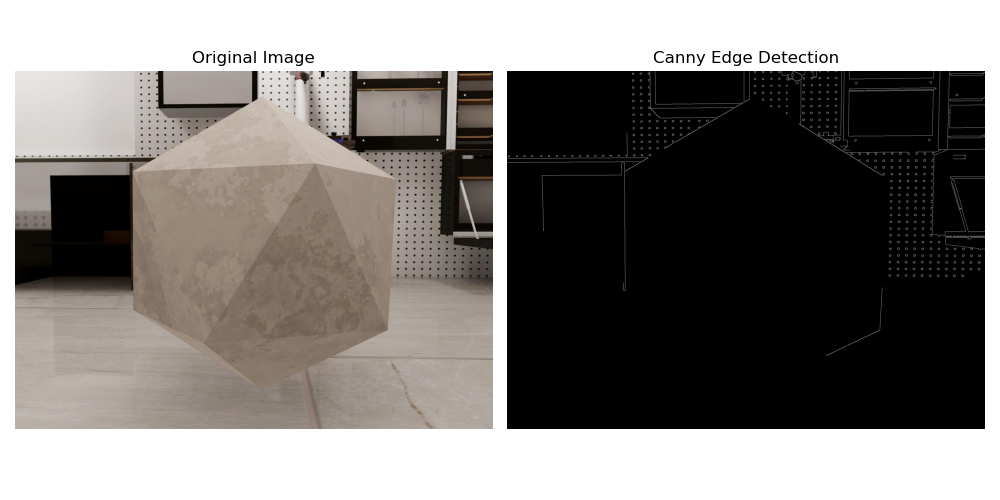

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = load_image_np("convexy.jpg")
depth_map = compute_depth(img)

# Apply Gaussian blur to the image
blurred = cv2.GaussianBlur(img, (3, 3), 0)

# Apply the Canny edge detector
edges = cv2.Canny(blurred, 50, 150)  # Adjust the threshold values as needed

# Display the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(1, 2, 2), plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection'), plt.axis('off')

plt.tight_layout()
plt.show()

## Sobel Operator

The Sobel operator/filter is a simple edge detection operator. It is used as part of the Canny edge detection algorithm. It calculates an approximation of the gradient of the image intensity at each pixel. The Sobel operator consists of two 3x3 convolution kernels, one for horizontal changes and one for vertical changes. 

Horizontal changes: This is computed by convolving I with a kernel Gx with odd size. For example for a kernel size of 3, Gx would be computed as:

\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix} 

Vertical changes: This is computed by convolving I with a kernel Gy with odd size. For example for a kernel size of 3, Gy would be computed as:

\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}

`dst = cv2.Sobel(src, ddepth, dx, dy, ksize[, scale[, delta[, borderType]]])
`

- src: Input image (single-channel, 8-bit or floating-point).
- ddepth: Depth of the output image. Set to -1 to use the same depth as the input image.
- dx: Order of the derivative in the x-direction (typically 0 or 1).
- dy: Order of the derivative in the y-direction (typically 0 or 1).
- ksize: Size of the Sobel kernel. It must be 1, 3, 5, or 7.
- scale: Optional scale factor for the computed derivative values. Default is 1.
- delta: Optional offset added to the computed derivative values. Default is 0.
- borderType: Pixel extrapolation method (see the cv2.copyMakeBorder() function). Default is cv2.BORDER_DEFAULT.

A larger k-size reveals more edges. The scale paramters will multiply the pixels values.


<IPython.core.display.Javascript object>


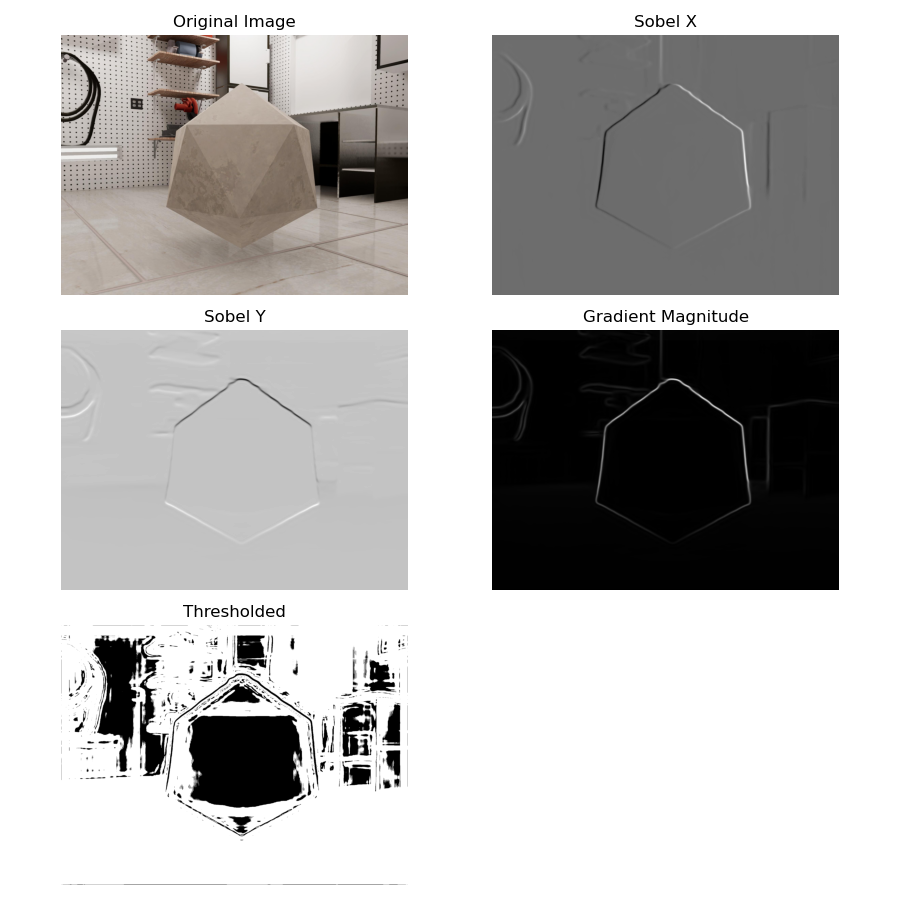

1241 by 1057: 3.5001797676086426
1057 by 1241: 2.1077284812927246


In [8]:
import cv2

img = load_image_np("4.jpg")
depth_map = compute_depth(img)

# Apply Sobel filter
sobelx = cv2.Sobel(depth_map, -1, 1, 0, ksize=7, scale=1)
sobely = cv2.Sobel(depth_map, -1, 0, 1, ksize=7, scale=1)

# Calculate gradient magnitude
gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)

# Display the results
plt.figure(figsize=(9, 9), layout="constrained")

plt.subplot(3, 2, 1), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(3, 2, 2), plt.imshow(sobelx, cmap='gray')
plt.title('Sobel X'), plt.axis('off')

plt.subplot(3, 2, 3), plt.imshow(sobely, cmap='gray')
plt.title('Sobel Y'), plt.axis('off')

plt.subplot(3, 2, 4), plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude'), plt.axis('off')

# Apply custom thresholding
threshold_min = 2
threshold_max = 255
edges_custom_threshold = np.zeros_like(gradient_magnitude)
edges_custom_threshold[(gradient_magnitude >= threshold_min) & (gradient_magnitude <= threshold_max)] = 255

plt.subplot(3, 2, 5), plt.imshow(edges_custom_threshold, cmap='gray')
plt.title('Thresholded'), plt.axis('off')

plt.tight_layout()
plt.show()
print(f"1241 by 1057: {gradient_magnitude[1057, 1241]}")
print(f"1057 by 1241: {gradient_magnitude[1241, 1057]}")

### Scharr Operator

`dst = cv2.Scharr(src, ddepth, dx, dy[, scale[, delta[, borderType]]])`

- src: Input image (single-channel, 8-bit or floating-point).
- ddepth: Depth of the output image. Set to -1 to use the same depth as the input image.
- dx: Order of the derivative in the x-direction (typically 0 or 1).
- dy: Order of the derivative in the y-direction (typically 0 or 1).
- scale: Optional scale factor for the computed derivative values. Default is 1.
- delta: Optional offset added to the computed derivative values. Default is 0.
- borderType: Pixel extrapolation method (see the cv2.copyMakeBorder() function). Default is cv2.BORDER_DEFAULT.


<IPython.core.display.Javascript object>


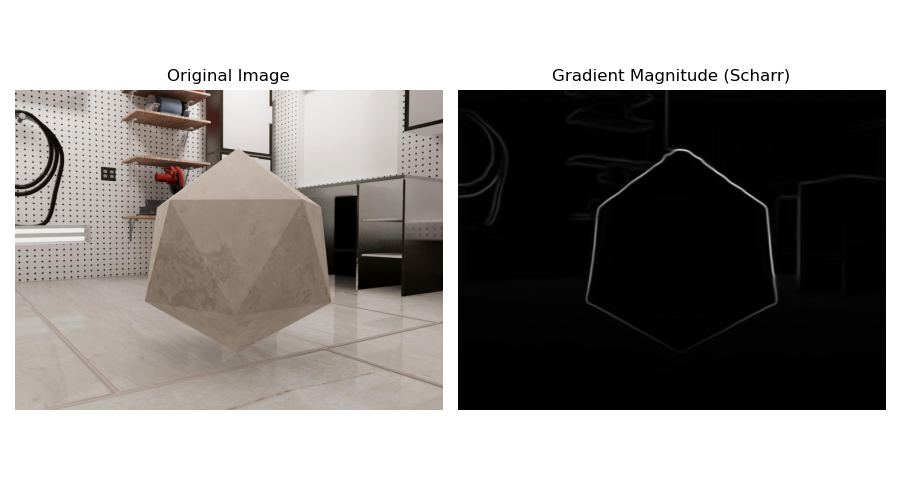

In [9]:
img = load_image_np("4.jpg")
depth_map = compute_depth(img)

# Apply the Scharr operator
scharrx = cv2.Scharr(depth_map, -1, 1, 0, scale=10)
scharry = cv2.Scharr(depth_map, -1, 0, 1, scale=10)

# Calculate gradient magnitude
gradient_magnitude = np.sqrt(scharrx**2 + scharry**2)

# Display the results
plt.figure(figsize=(9, 5), layout="constrained")

plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(1, 2, 2), plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude (Scharr)'), plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
from skimage import color, feature, io
from skimage.feature import blob_log


img = load_image_np("33.jpg")
depth_map = compute_depth(img)

mask = create_mask(img)
masked = mask_out(mask, depth_map)

min_sigma=20
max_sigma=50
threshold=.01

# Detect blobs using Laplacian of Gaussian (LoG)
blobs_log = blob_fog(masked, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)

# Plot the image with detected blobs
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title('Image with Detected Blobs')

# Plot the detected blobs on the image
for blob in blobs_log:
    y, x, r = blob
    c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
    plt.gca().add_patch(c)

plt.show()

/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torchvision/transforms/functional.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/torch/csrc/utils/tensor_numpy.cpp:199.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.


2023-12-04 22:09:44.590307585 [E:onnxruntime:, inference_session.cc:1785 operator()] Exception during initialization: /onnxruntime_src/onnxruntime/core/framework/bfc_arena.cc:376 void* onnxruntime::BFCArena::AllocateRawInternal(size_t, bool, onnxruntime::Stream*, bool, onnxruntime::WaitNotificationFn) Failed to allocate memory for requested buffer of size 7077888



RuntimeException: [ONNXRuntimeError] : 6 : RUNTIME_EXCEPTION : Exception during initialization: /onnxruntime_src/onnxruntime/core/framework/bfc_arena.cc:376 void* onnxruntime::BFCArena::AllocateRawInternal(size_t, bool, onnxruntime::Stream*, bool, onnxruntime::WaitNotificationFn) Failed to allocate memory for requested buffer of size 7077888


# RembG Models Comparison

Rembg provides a couple of models in their [releases](https://github.com/danielgatis/rembg/releases/) page. Among them are:
    
    1. Silueta
    2. isnet-general-use
    3. u2net (default)
    4. sam

The cells below will compar the 4 models in terms of accuracy and speed on the Car1 image.

<IPython.core.display.Javascript object>


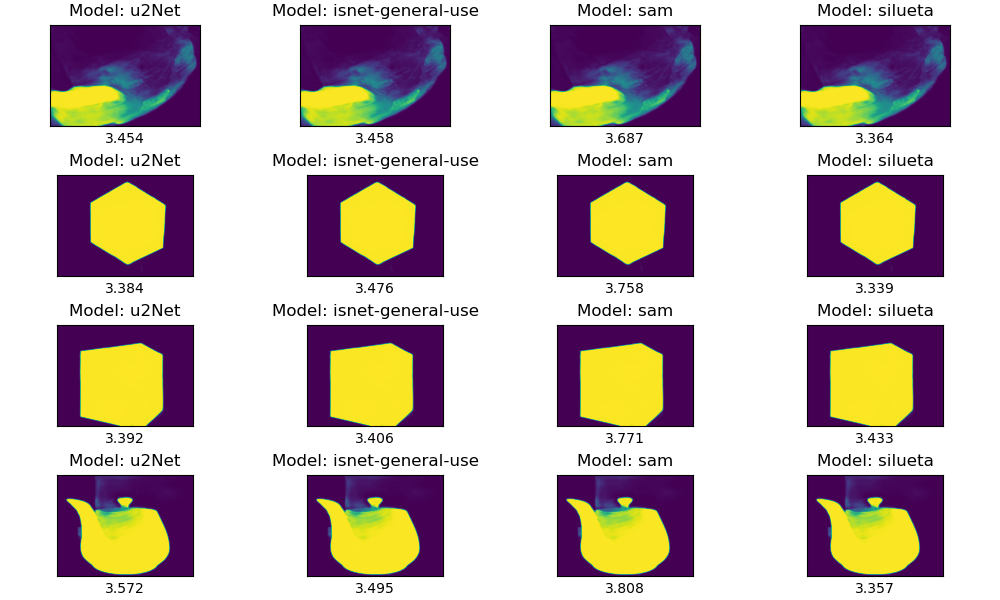

EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecut

EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecut

EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecut

In [45]:
import time
model_names = [ "u2Net", "isnet-general-use", "sam", "silueta" ]
img = load_image("car1.jpg")
images = [
    load_image("car1.jpg"),
    load_image("convexy.jpg"),
    load_image("33.jpg"),
    load_image("0.3.jpg"),
]
fig, ax = plt.subplots(len(images),len(model_names), figsize=(10,6), layout="constrained")
h = 0

for image in images:    
    for i in range(len(model_names)):    
        model = model_names[i]
        start = time.time()
        session = new_session( model_names[i] )
        mask = remove(image, only_mask=True, post_process_mask=False)
        stop = time.time() - start
        ax[h][i].set_title(f"Model: {model}")
        ax[h][i].imshow(mask)
        ax[h][i].set_xlabel( round(stop,3))         
        ax[h][i].tick_params(axis='both', which='both',         
               bottom=False, top=False, left=False,           
               right=False, labelbottom=False,  labelleft=False)      

        
        
    h+=1

In [ ]:
# Define Blob Detector for 